In [22]:
%pip install grad-cam

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [23]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from pathlib import Path
from PIL import Image

from torchvision import models, transforms

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [24]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

project_root = Path.cwd().parent

model_path = (
    project_root
    / "models"
    / "efficientnet_b0_oral_cancer.pth"
)

test_dir = (
    project_root
    / "dataset"
    / "processed"
    / "test"
)

gradcam_output_dir = (
    project_root
    / "models"
    / "gradcam_results"
)

gradcam_output_dir.mkdir(
    parents=True,
    exist_ok=True
)

print("Using device:", device)
print("Model exists:", model_path.exists())
print("Test directory exists:", test_dir.exists())
print("Grad-CAM output:", gradcam_output_dir)

Using device: cpu
Model exists: True
Test directory exists: True
Grad-CAM output: e:\PROJECTS\OralScan-AI\models\gradcam_results


In [25]:
checkpoint = torch.load(
    model_path,
    map_location=device
)

class_names = checkpoint["class_names"]
class_to_idx = checkpoint["class_to_idx"]

print("Classes:", class_names)
print("Class mapping:", class_to_idx)

Classes: ['CANCER', 'NON CANCER']
Class mapping: {'CANCER': 0, 'NON CANCER': 1}


In [26]:
model = models.efficientnet_b0(
    weights=None
)

num_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(
        num_features,
        len(class_names)
    )
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()

print("Model loaded successfully.")

Model loaded successfully.


In [27]:
image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [28]:
IMAGE_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

test_images = []

for class_folder in test_dir.iterdir():

    if not class_folder.is_dir():
        continue

    for image_path in class_folder.iterdir():

        if image_path.suffix.lower() in IMAGE_EXTENSIONS:
            test_images.append(image_path)

print("Total test images found:", len(test_images))

selected_image_path = random.choice(test_images)

print("Selected image:")
print(selected_image_path)

Total test images found: 93
Selected image:
e:\PROJECTS\OralScan-AI\dataset\processed\test\NON CANCER\431.jpeg


In [29]:
original_image = Image.open(
    selected_image_path
).convert("RGB")

resized_image = original_image.resize(
    (224, 224)
)

input_tensor = image_transform(
    original_image
).unsqueeze(0)

input_tensor = input_tensor.to(device)

print("Input tensor shape:", input_tensor.shape)

Input tensor shape: torch.Size([1, 3, 224, 224])


In [30]:
with torch.no_grad():

    output = model(input_tensor)

    probabilities = torch.softmax(
        output,
        dim=1
    )

    predicted_index = output.argmax(
        dim=1
    ).item()

    confidence = probabilities[
        0,
        predicted_index
    ].item()

predicted_class = class_names[
    predicted_index
]

true_class = selected_image_path.parent.name

print("True class:", true_class)
print("Predicted class:", predicted_class)
print(f"Confidence: {confidence * 100:.2f}%")

True class: NON CANCER
Predicted class: NON CANCER
Confidence: 99.33%


In [31]:
target_layers = [
    model.features[-1]
]

print(target_layers)

[Conv2dNormActivation(
  (0): Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): SiLU(inplace=True)
)]


In [32]:
cam = GradCAM(
    model=model,
    target_layers=target_layers
)

targets = [
    ClassifierOutputTarget(
        predicted_index
    )
]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0]

print(
    "Grad-CAM shape:",
    grayscale_cam.shape
)

Grad-CAM shape: (224, 224)


In [33]:
rgb_image = np.array(
    resized_image
).astype(np.float32)

rgb_image = rgb_image / 255.0

print(
    "Image range:",
    rgb_image.min(),
    rgb_image.max()
)

Image range: 0.003921569 0.91764706


In [34]:
gradcam_overlay = show_cam_on_image(
    rgb_image,
    grayscale_cam,
    use_rgb=True
)

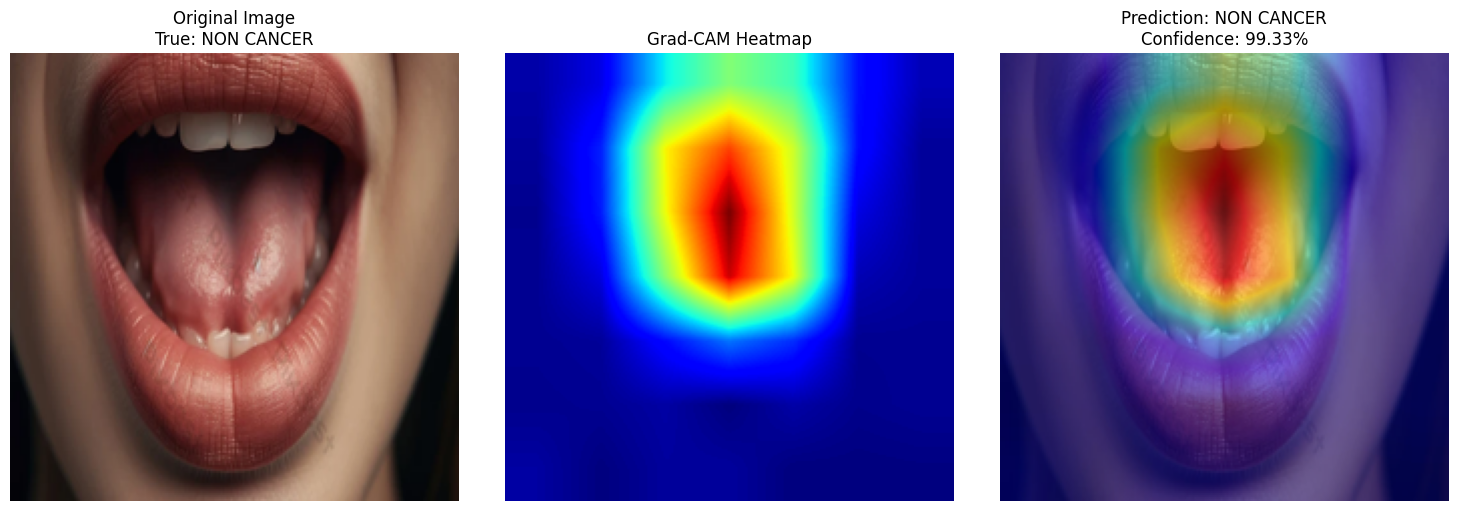

In [35]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(resized_image)
plt.title(
    f"Original Image\n"
    f"True: {true_class}"
)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(
    grayscale_cam,
    cmap="jet"
)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gradcam_overlay)
plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence * 100:.2f}%"
)
plt.axis("off")

plt.tight_layout()
plt.show()

In [36]:
output_filename = (
    f"{selected_image_path.stem}"
    f"_gradcam.png"
)

output_path = (
    gradcam_output_dir
    / output_filename
)

Image.fromarray(
    gradcam_overlay
).save(output_path)

print("Grad-CAM image saved at:")
print(output_path)

Grad-CAM image saved at:
e:\PROJECTS\OralScan-AI\models\gradcam_results\431_gradcam.png


In [37]:
def generate_gradcam(
    image_path,
    model,
    class_names,
    target_layers,
    device
):
    image_path = Path(image_path)

    original_image = Image.open(
        image_path
    ).convert("RGB")

    resized_image = original_image.resize(
        (224, 224)
    )

    input_tensor = image_transform(
        original_image
    ).unsqueeze(0).to(device)

    with torch.no_grad():

        output = model(input_tensor)

        probabilities = torch.softmax(
            output,
            dim=1
        )

        predicted_index = output.argmax(
            dim=1
        ).item()

        confidence = probabilities[
            0,
            predicted_index
        ].item()

    predicted_class = class_names[
        predicted_index
    ]

    cam = GradCAM(
        model=model,
        target_layers=target_layers
    )

    targets = [
        ClassifierOutputTarget(
            predicted_index
        )
    ]

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )[0]

    rgb_image = np.array(
        resized_image
    ).astype(np.float32) / 255.0

    overlay = show_cam_on_image(
        rgb_image,
        grayscale_cam,
        use_rgb=True
    )

    return {
        "prediction": predicted_class,
        "confidence": confidence,
        "heatmap": grayscale_cam,
        "overlay": overlay,
        "original": resized_image
    }

In [38]:
result = generate_gradcam(
    image_path=selected_image_path,
    model=model,
    class_names=class_names,
    target_layers=target_layers,
    device=device
)

print("Prediction:", result["prediction"])
print(
    f"Confidence: "
    f"{result['confidence'] * 100:.2f}%"
)

Prediction: NON CANCER
Confidence: 99.33%


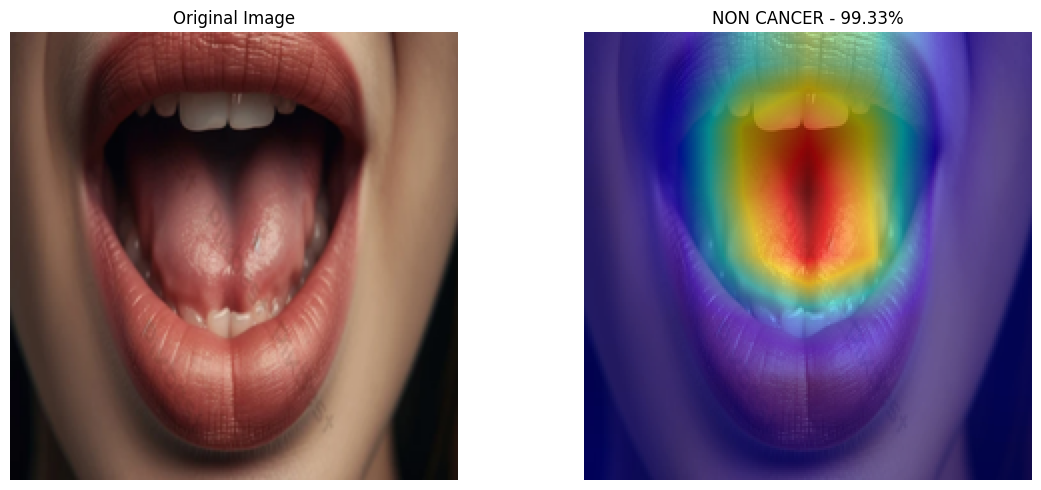

In [39]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(result["original"])
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result["overlay"])
plt.title(
    f"{result['prediction']} - "
    f"{result['confidence'] * 100:.2f}%"
)
plt.axis("off")

plt.tight_layout()
plt.show()